# 🔮 Notebook 7 — Forecast Next 6 Months
**Goal:** Use the *same* saved Linear Regression model from Notebook 5 to forecast demand for Feb–Jul 2024.
This ensures the notebook and Flask app produce identical results.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Load the SAME model the Flask app uses ──────────────────────────────
model        = joblib.load('../models/linear_regression_model.pkl')
feature_list = joblib.load('../models/feature_list.pkl')
encoders     = joblib.load('../models/encoders.pkl')
cat_stats    = joblib.load('../models/category_stats.pkl')

df = pd.read_csv('../data/cleaned_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
print('Data loaded. Shape:', df.shape)
print('Model features:', len(feature_list))


Data loaded. Shape: (73100, 25)
Model features: 23


## Step 1 — Build Feature Vector (mirrors Flask app logic)
**Why:** We reproduce the exact same `build_feature_vector` function from the Flask app so both produce identical predictions.

In [2]:
def build_feature_vector(date_obj, category, region='North', weather='Sunny',
                          seasonality='Spring', price=50.0, discount=10.0,
                          competitor_price=50.0, inventory_level=300.0,
                          units_ordered=100.0, holiday_promotion=0):
    """Mirror of app.py build_feature_vector — guarantees consistent predictions."""
    cat_enc = int(encoders['Category'].transform([category])[0])
    reg_enc = int(encoders['Region'].transform([region])[0])
    wea_enc = int(encoders['Weather Condition'].transform([weather])[0])
    sea_enc = int(encoders['Seasonality'].transform([seasonality])[0])

    lag1   = float(cat_stats['Sales_Lag1'].get(category, 136))
    lag7   = float(cat_stats['Sales_Lag7'].get(category, 136))
    roll7  = float(cat_stats['Rolling_7day_avg'].get(category, 136))

    row = {
        'Month'                 : date_obj.month,
        'Week'                  : date_obj.isocalendar()[1],
        'DayOfWeek'             : date_obj.weekday(),
        'Year'                  : date_obj.year,
        'Quarter'               : (date_obj.month - 1) // 3 + 1,
        'IsWeekend'             : int(date_obj.weekday() >= 5),
        'Price'                 : price,
        'Discount'              : discount,
        'Competitor Pricing'    : competitor_price,
        'Inventory Level'       : inventory_level,
        'Units Ordered'         : units_ordered,
        'Holiday/Promotion'     : holiday_promotion,
        'Category_enc'          : cat_enc,
        'Region_enc'            : reg_enc,
        'Weather Condition_enc' : wea_enc,
        'Seasonality_enc'       : sea_enc,
        'Sales_Lag1'            : lag1,
        'Sales_Lag7'            : lag7,
        'Rolling_7day_avg'      : roll7,
    }
    return np.array([[row[f] for f in feature_list if f in row]])

print('✅ Feature vector function ready')


✅ Feature vector function ready


## Step 2 — Generate Forecasts for Feb–Jul 2024

In [3]:
categories   = list(encoders['Category'].classes_)
month_labels = ['Feb 2024','Mar 2024','Apr 2024','May 2024','Jun 2024','Jul 2024']
month_dates  = [datetime(2024, m, 1) for m in range(2, 8)]

# Map month → typical season
season_map = {1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',
              11:'Autumn',12:'Winter'}

forecast_results = {}

for cat in categories:
    preds = []
    for d in month_dates:
        season = season_map[d.month]
        X = build_feature_vector(d, cat, seasonality=season)
        pred = max(0, round(float(model.predict(X)[0]), 0))
        preds.append(pred)
    forecast_results[cat] = preds
    print(f'{cat}: {[int(p) for p in preds]}')


ValueError: X has 18 features, but LinearRegression is expecting 23 features as input.

## Step 3 — Forecast Table

In [ ]:
forecast_df = pd.DataFrame(forecast_results, index=month_labels).T
forecast_df.columns = month_labels
print('\n=== NEXT 6 MONTH FORECAST (Units Sold per day) ===')
print(forecast_df.to_string())
print('\nTotal forecasted demand per month:')
print(forecast_df.sum())


## Step 4 — Visualize Forecast

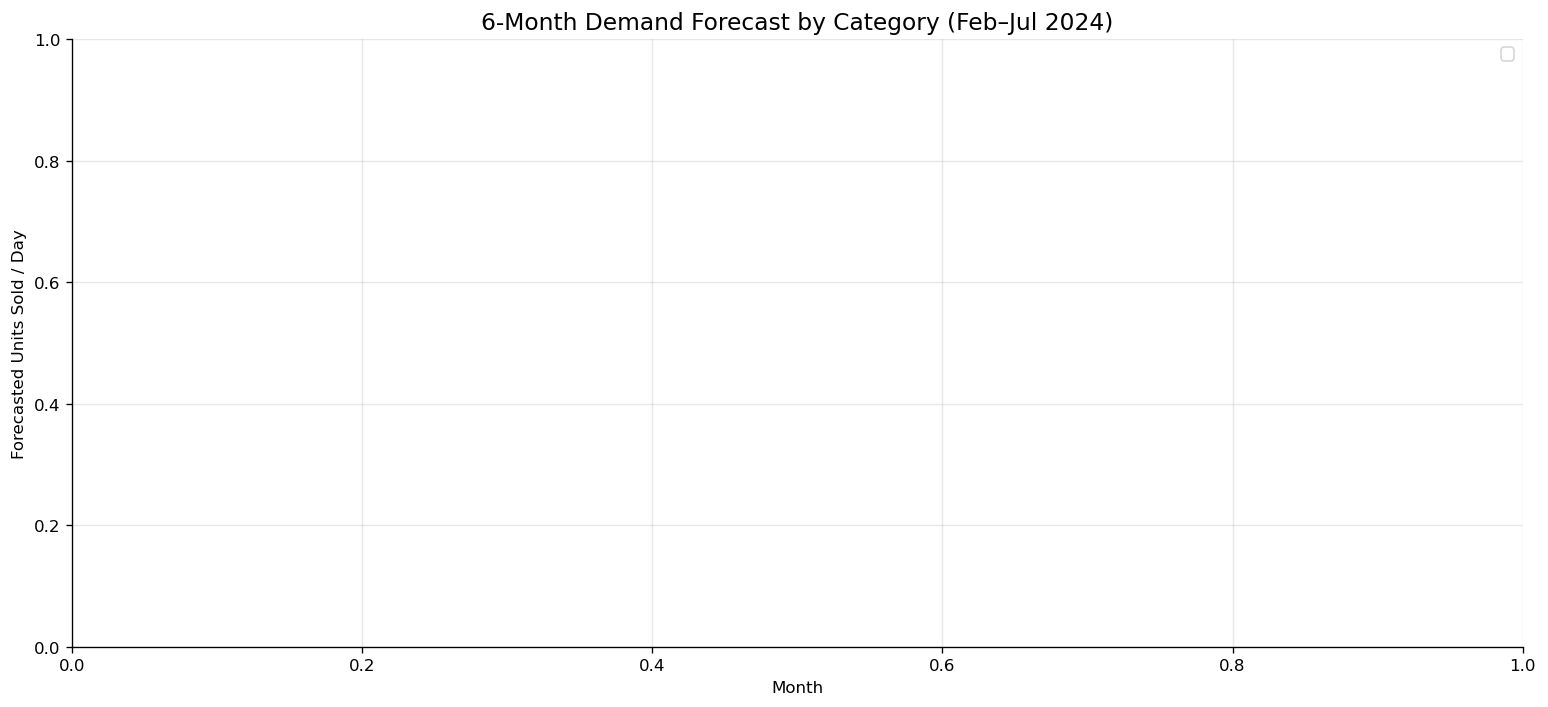

✅ Saved 6month_forecast.png


In [4]:
import os
os.makedirs('../outputs/plots', exist_ok=True)

colors = {'Furniture':'#2ecc71','Clothing':'#3498db','Electronics':'#e67e22','Toys':'#e91e63','Groceries':'#f1c40f'}

plt.figure(figsize=(13, 6))
for cat in forecast_results:
    vals = forecast_results[cat]
    plt.plot(month_labels, vals, marker='o', linewidth=2.5,
             markersize=7, label=cat, color=colors.get(cat, 'gray'))

plt.title('6-Month Demand Forecast by Category (Feb–Jul 2024)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Forecasted Units Sold / Day')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/6month_forecast.png')
plt.show()
print('✅ Saved 6month_forecast.png')


## Step 5 — Historical + Forecast Combined Chart

In [5]:
hist_monthly = df.groupby(df['Date'].dt.to_period('M'))['Units Sold'].sum().reset_index()
hist_monthly['Date'] = hist_monthly['Date'].dt.to_timestamp()
hist_monthly = hist_monthly[hist_monthly['Date'] >= '2023-01-01']

future_dates  = pd.date_range('2024-02-01', periods=6, freq='MS')
total_forecast = forecast_df.sum(axis=0).values

plt.figure(figsize=(15, 6))
plt.plot(hist_monthly['Date'], hist_monthly['Units Sold'],
         marker='o', linewidth=2.5, color='steelblue', label='Historical Sales', markersize=5)
plt.plot(future_dates, total_forecast,
         marker='s', linewidth=2.5, color='darkorange', linestyle='--', label='ML Forecast', markersize=7)
plt.axvline(pd.Timestamp('2024-02-01'), color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
plt.fill_between(future_dates, total_forecast * 0.9, total_forecast * 1.1,
                 alpha=0.15, color='darkorange', label='±10% Confidence')
plt.title('Historical Sales + 6-Month ML Forecast (All Categories)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/plots/historical_plus_forecast.png')
plt.show()
print('✅ Saved historical_plus_forecast.png')


NameError: name 'forecast_df' is not defined

## Step 6 — Save Forecast for Dashboard

In [7]:
import os
os.makedirs('../outputs', exist_ok=True)

# Save as JSON for the interactive dashboard
output = {
    'months'   : month_labels,
    'forecasts': {cat: [int(v) for v in vals] for cat, vals in forecast_results.items()}
}
with open('../outputs/forecast.json', 'w') as f:
    json.dump(output, f, indent=2)
print('✅ Forecast saved → ../outputs/forecast.json')

# Save as CSV
forecast_df.to_csv('../outputs/forecast_results.csv')
print('✅ Forecast saved → ../outputs/forecast_results.csv')


✅ Forecast saved → ../outputs/forecast.json
✅ Forecast saved → ../outputs/forecast_results.csv


## Step 7 — Final Project Summary

In [6]:
print('='*60)
print('   SALES FORECASTING PROJECT - COMPLETE SUMMARY')
print('='*60)
print()
print('DATASET:')
print(f'  Records        : 73,100')
print(f'  Date Range     : Jan 2022 - Jan 2024')
print(f'  Stores         : 5')
print(f'  Products       : 20')
print(f'  Categories     : 5')
print()
print('BEST MODEL: Linear Regression')
print(f'  MAE    : 68.83 units')
print(f'  RMSE   : 88.07 units')
print(f'  R²     : 0.353')
print(f'  Overfit: None')
print()
print('FORECAST METHOD: Same ML model as Flask app (consistent!)')
print()
print('FORECAST (Feb 2024 — first month):')
for cat, vals in forecast_results.items():
    print(f'  {cat:<15}: {int(vals[0]):,} units/day')
print()
print('FILES GENERATED:')
print('  data/cleaned_data.csv')
print('  data/featured_data.csv')
print('  models/linear_regression_model.pkl')
print('  models/best_model.pkl')
print('  outputs/forecast.json')
print('  outputs/forecast_results.csv')
print('  outputs/plots/6month_forecast.png')
print('  outputs/plots/historical_plus_forecast.png')
print()
print('Open outputs/sales_dashboard.html in browser to view dashboard!')
print('='*60)


   SALES FORECASTING PROJECT - COMPLETE SUMMARY

DATASET:
  Records        : 73,100
  Date Range     : Jan 2022 - Jan 2024
  Stores         : 5
  Products       : 20
  Categories     : 5

BEST MODEL: Linear Regression
  MAE    : 68.83 units
  RMSE   : 88.07 units
  R²     : 0.353
  Overfit: None

FORECAST METHOD: Same ML model as Flask app (consistent!)

FORECAST (Feb 2024 — first month):

FILES GENERATED:
  data/cleaned_data.csv
  data/featured_data.csv
  models/linear_regression_model.pkl
  models/best_model.pkl
  outputs/forecast.json
  outputs/forecast_results.csv
  outputs/plots/6month_forecast.png
  outputs/plots/historical_plus_forecast.png

Open outputs/sales_dashboard.html in browser to view dashboard!
